In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [11]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [3]:
############################
#LOADING DATA

In [4]:
#NEEDED TO PLOT THE CORRECT DATA
data_type="Tracked_Area"

In [5]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"CL_nonCL_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [41]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

In [42]:
############################
#PLOTTING

In [43]:
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] > 1)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [44]:
def LoadAllCloudBase():
    dir2 = dir + f'Project_Algorithms/Tracking_Algorithms/'
    in_file = dir2 + f"all_cloudbase_{res}_{t_res}_{Np_str}.pkl"
    with open(in_file, 'rb') as f:
        all_cloudbase = pickle.load(f)
    return(all_cloudbase)
min_all_cloudbase=np.nanmin(LoadAllCloudBase())
all_cloudbase=min_all_cloudbase
print(f"Minimum Cloudbase is: {min_all_cloudbase}\n")

Minimum Cloudbase is: 1.2463867664337158



In [45]:
def plot_updraft_profiles(type1, type2, type3='ALL'):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax = ax.flatten()

    factor = 1
    switch = 1

    profile_labels = {
        type1: {'label': type1, 'linestyle': 'solid', 'color': 'k', 'alpha': 0.1, 'hatch': None},
        type2: {'label': type2, 'linestyle': 'dashed', 'color': 'k', 'alpha': 0.2, 'hatch': '///'}
    }

    profile_types = ['general', 'cloudy']

    for i, prof_type in enumerate(profile_types):
        for t in [type1, type2]:
            array_name = f"{t}_{type3}_profile_array_{prof_type}"
            SE_name = f"{t}_{type3}_profile_array_{prof_type}_SE"
            profile_array = globals()[array_name]
            SE_array = globals()[SE_name]

            profile = averaged_profiles(profile_array)
            SE_profile = SE_array

            ax[i].plot(profile[:, 0], profile[:, 1],
                       color=profile_labels[t]['color'],
                       linestyle=profile_labels[t]['linestyle'],
                       label=profile_labels[t]['label'])

            fill_kwargs = {
                'alpha': profile_labels[t]['alpha'],
                'linewidth': 0.0
            }

            if profile_labels[t]['hatch'] is None:
                fill_kwargs['color'] = profile_labels[t]['color']
            else:
                fill_kwargs['color'] = 'none'
                fill_kwargs['edgecolor'] = profile_labels[t]['color']
                fill_kwargs['hatch'] = profile_labels[t]['hatch']

            ax[i].fill_betweenx(
                profile[:, 1],
                profile[:, 0] - factor * SE_profile[:, 0] * switch,
                profile[:, 0] + factor * SE_profile[:, 0] * switch,
                **fill_kwargs
            )

        ax[i].set_xlabel(r'A ($km^2$)')
        ax[i].set_ylabel('z (km)')
        ax[i].axhline(all_cloudbase, color='purple', linestyle='dashed')
        ax[i].set_title(f'{prof_type.capitalize()} Profile')
        ax[i].legend()

    fix_x_limits(ax)
    fix_y_limits(ax)

    plt.suptitle(f'{type3} {type1} vs {type2} Updrafts Area Profile')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

(-2.389647714811473, 50.182602011040935)
(-0.7796000954695046, 17.05360203469172)


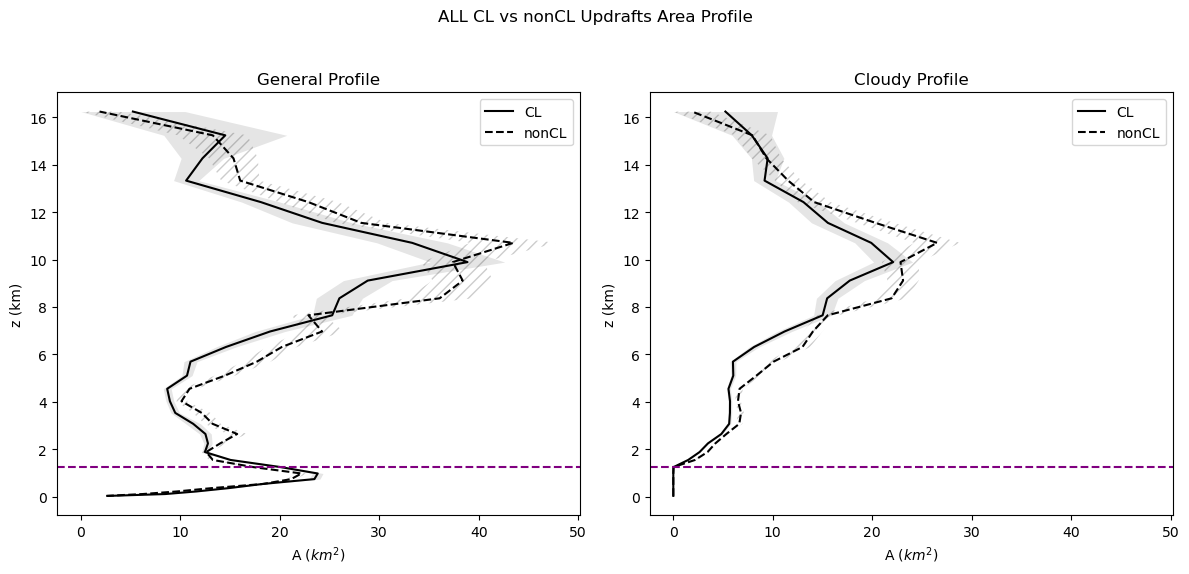

In [46]:
plot_updraft_profiles('CL', 'nonCL','ALL')

(-0.5404987899745758, 28.051572371093414)
(-0.1440493461675942, 3.7070362993516026)


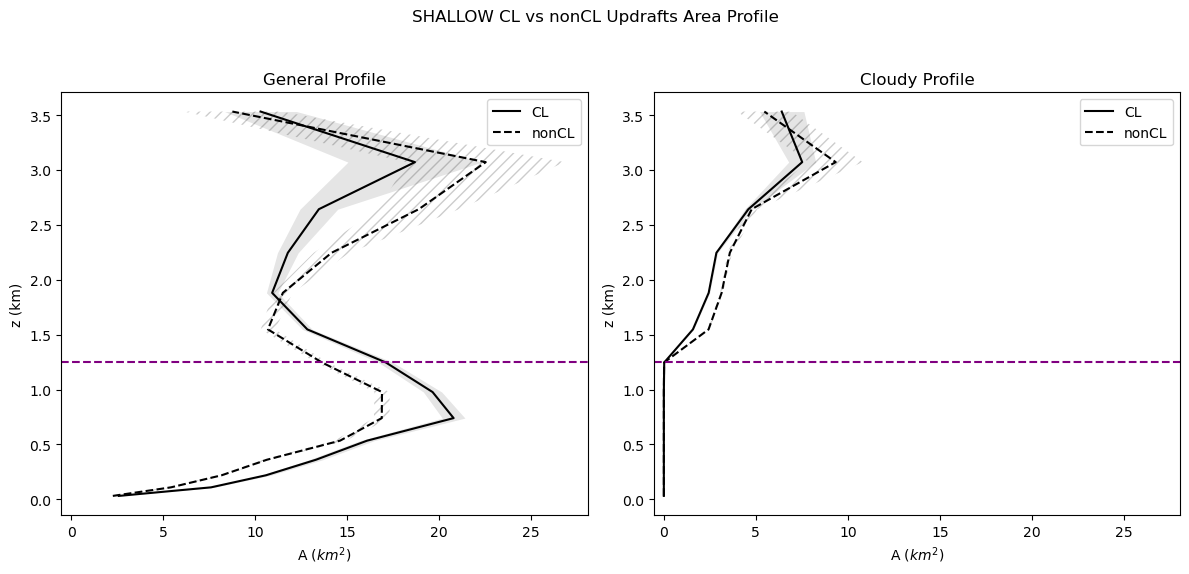

In [47]:
plot_updraft_profiles('CL', 'nonCL','SHALLOW')

(-3.102360176058774, 65.14956369723424)
(-0.7796000954695046, 17.05360203469172)


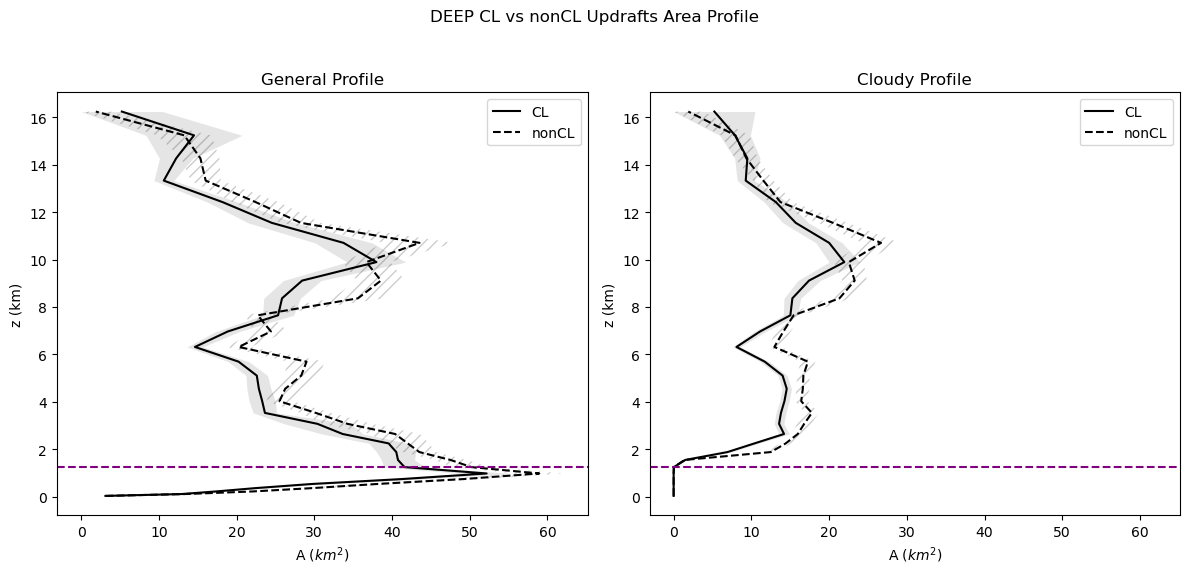

In [50]:
plot_updraft_profiles('CL', 'nonCL','DEEP')

In [51]:
#######################
#SBZ vs nonSBZ

In [52]:
############################
#PLOTTING

In [53]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"SBZ_nonSBZ_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [57]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    # globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

(-4.201899189359143, 88.23988297654199)
(-0.7796000954695046, 17.05360203469172)


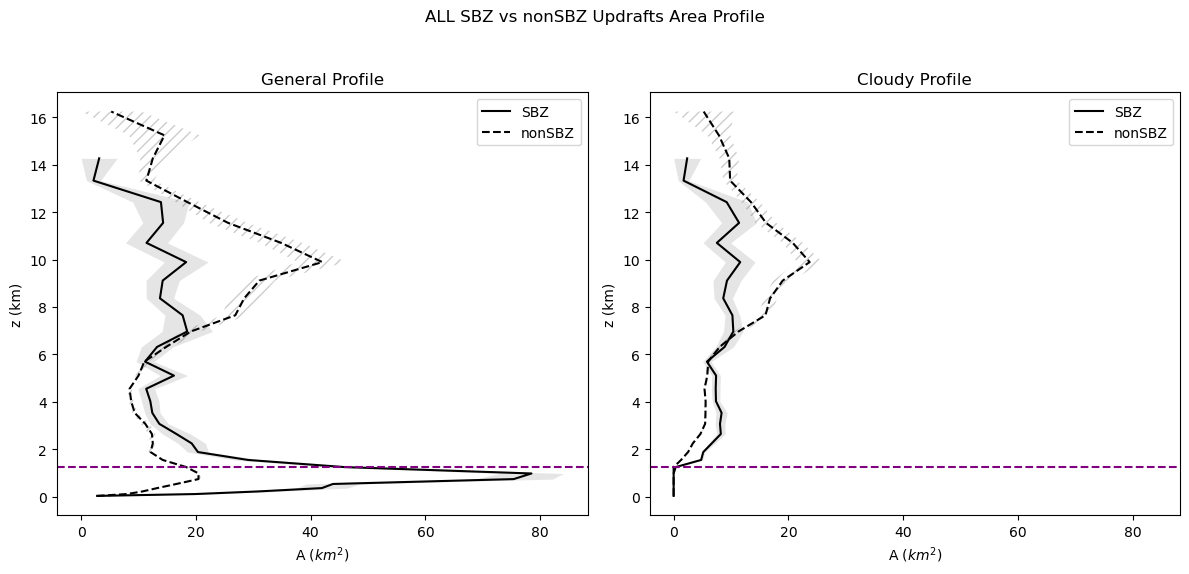

In [58]:
plot_updraft_profiles('SBZ', 'nonSBZ','ALL')

(-2.7240137467644967, 85.23806973821199)
(-0.1440493461675942, 3.7070362993516026)


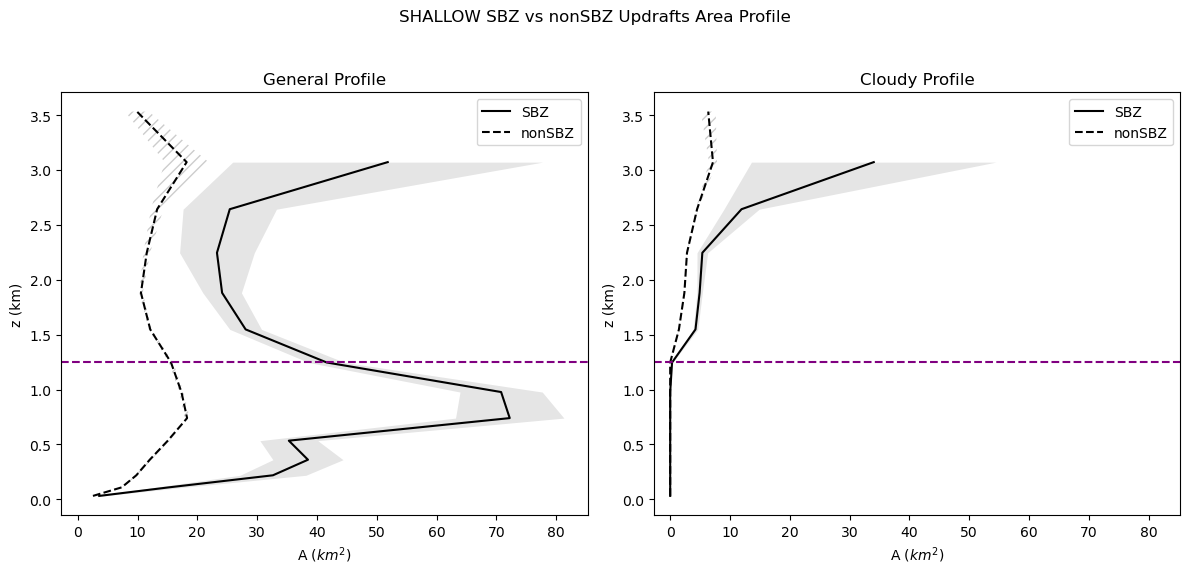

In [60]:
plot_updraft_profiles('SBZ', 'nonSBZ','SHALLOW')

(-6.029271405256953, 126.614699510396)
(-0.7796000954695046, 17.05360203469172)


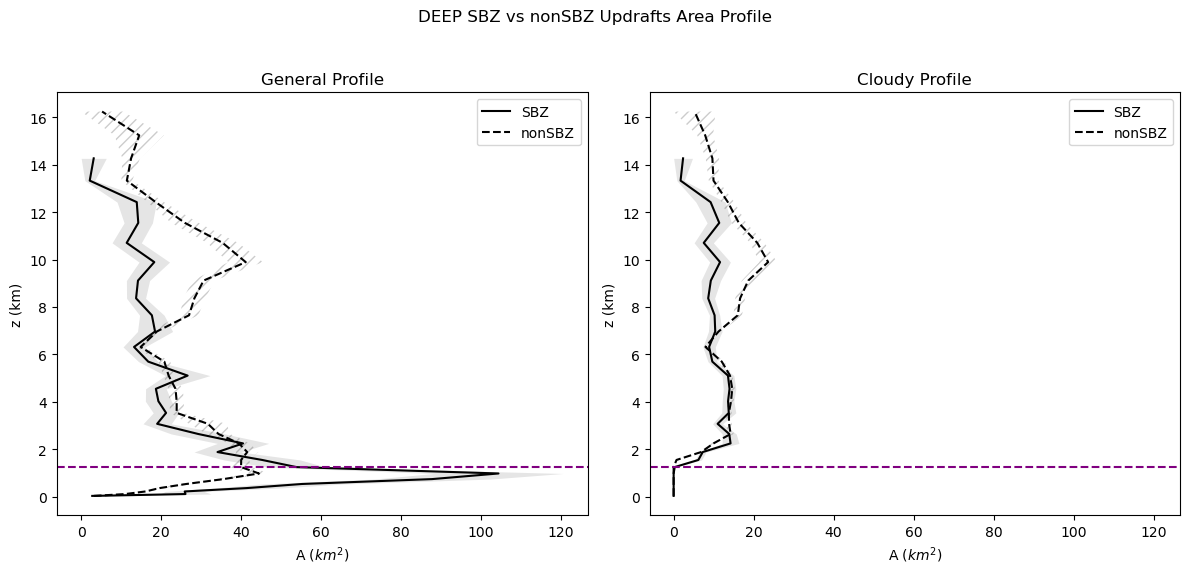

In [61]:
plot_updraft_profiles('SBZ', 'nonSBZ','DEEP')

In [64]:
#######################
#COLD POOL

In [65]:
#############################
#PLOTTING

In [66]:
# #OLD
# #LOADING BACK IN
# dir2=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file=dir2+f"ColdPool_tracked_Area_profiles_{res}_{t_res}_{Np_str}.h5"

# with open(input_file, "rb") as f:
#     profile_dict = pickle.load(f)

# # Dynamically create variables from the dictionary
# for var_name, value in profile_dict.items():
#     globals()[var_name] = value  # Assign to global namespace

In [67]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

(-59.677991856508825, 195.89488725795113)
(-0.7796000954695046, 17.05360203469172)


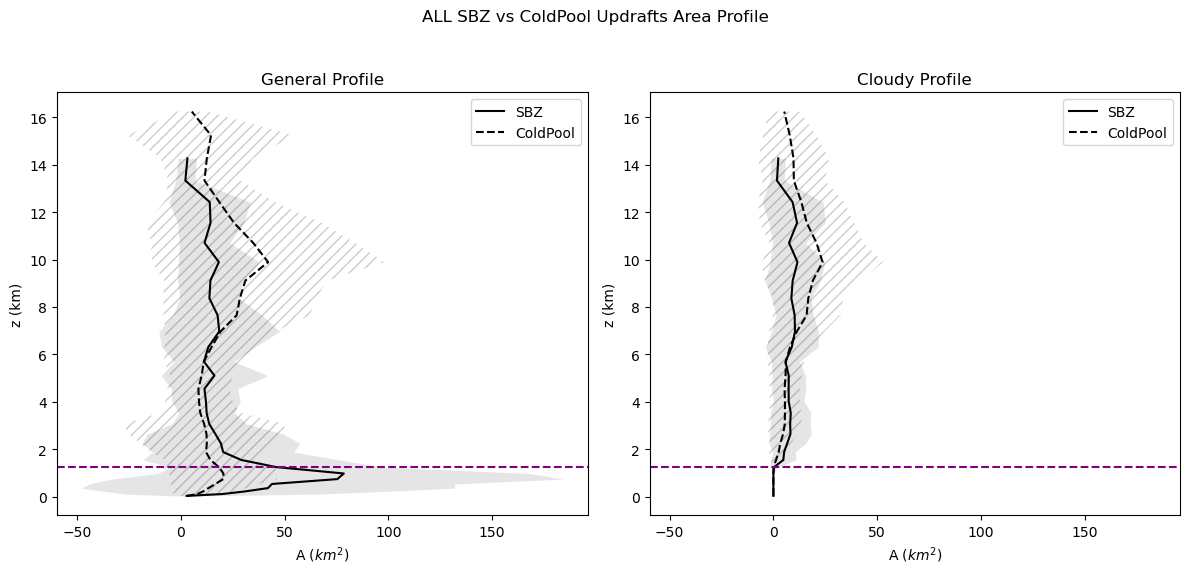

In [70]:
plot_updraft_profiles('SBZ', 'ColdPool','ALL')

(-63.10145604251227, 194.17917947711172)
(-0.1440493461675942, 3.7070362993516026)


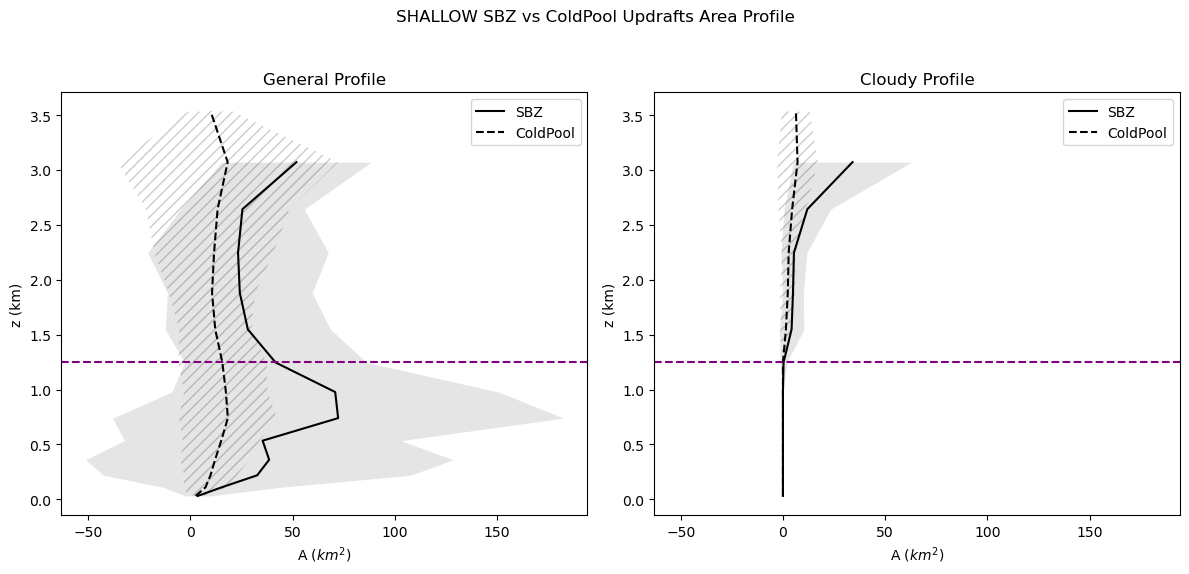

In [71]:
plot_updraft_profiles('SBZ', 'ColdPool','SHALLOW')

(-64.33067246544894, 237.32658434353252)
(-0.7796000954695046, 17.05360203469172)


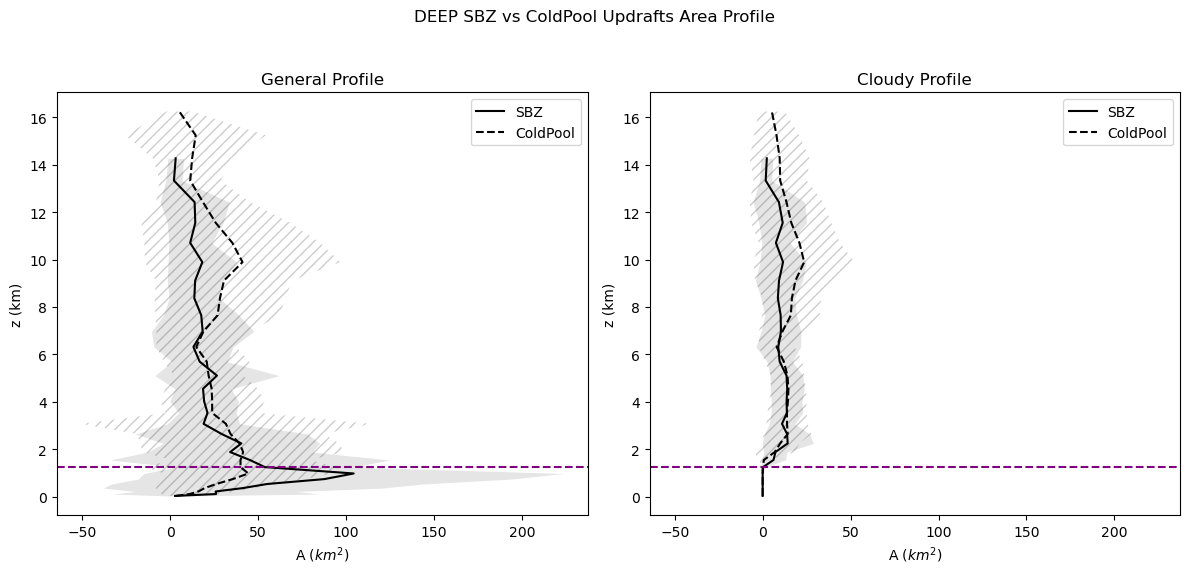

In [73]:
plot_updraft_profiles('SBZ', 'ColdPool','DEEP')